In [1]:
library(tidyverse)
library(glue)

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] glue_1.7.0      lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1  
 [5] dplyr_1.1.4     purrr_1.0.2     readr_2.1.5     tidyr_1.3.1    
 [9] tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        digest_0.6.36      uuid_1.2-0         timechange_0.3.0  
 [9] jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4    gtable_0.3.6      
[13] pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1      cli_3.6.3         
[17] IRkernel_1.3.2     fastmap_1.2.0      repr_1.1.7         withr_3.0

In [3]:
consensus_to_original<- read_tsv("./data-preparation/global-alignment/combined_alignment_stats.tsv")

Rows: 252 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
contigs_table <- read_tsv("viralmetagenome-out/combined/contigs_overview.tsv")%>%
    mutate(is_external_reference_scaffold = ifelse(grepl("NODE|k\\d{3}_", `(cluster) centroid`), FALSE, TRUE),
        distance = gsub(".*-","",reference_distance))

Rows: 58 Columns: 173
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (24): index, sample, cluster, step, (annotation) subject, (annotation) ...
dbl (148): (annotation) pident, (annotation) qlen, (annotation) slen, (annot...
lgl   (1): (failed_mapped) mapped reads

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
contigs_subset <- contigs_table %>%
    group_by(`(annotation) segment`, reference_distance) %>%
    arrange(desc(`(checkv) completeness`)) %>%
    slice(1)

Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


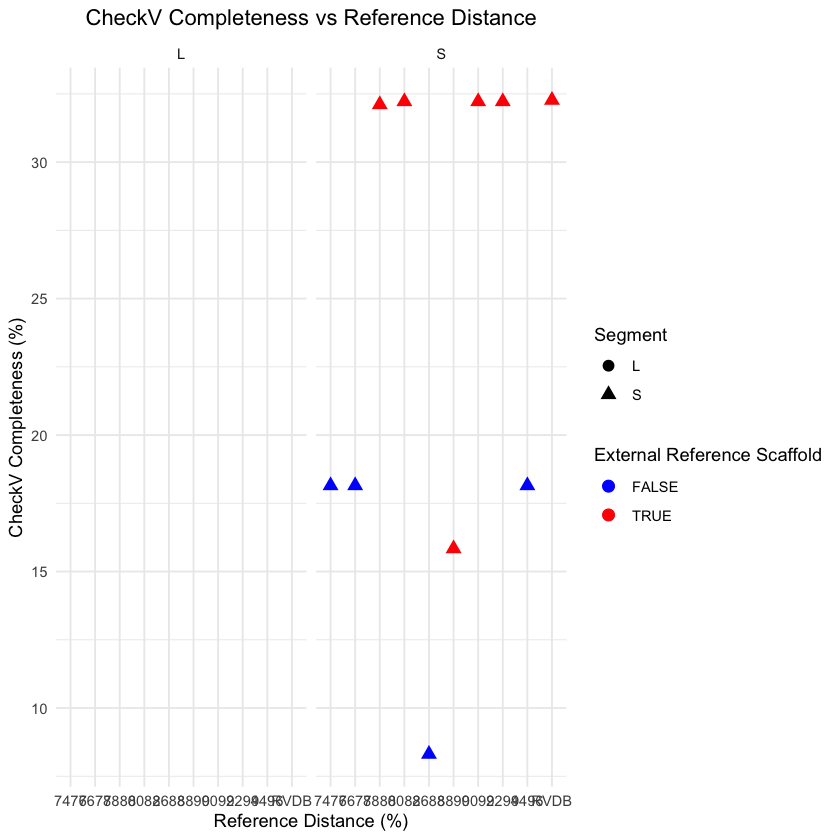

In [24]:
ggplot(contigs_subset, aes(x=as.factor(distance), y=`(checkv) completeness`, color=is_external_reference_scaffold, shape=`(annotation) segment`)) +
    geom_point(size=3) +
    facet_wrap(~`(annotation) segment`) +
    theme_minimal() +
    labs(x="Reference Distance (%)", y="CheckV Completeness (%)", color="External Reference Scaffold", shape="Segment") +
    scale_color_manual(values=c("TRUE"="red", "FALSE"="blue")) +
    ggtitle("CheckV Completeness vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

In [22]:
contigs_subset%>%filter(distance=="8890")%>%
    select(`(cluster) centroid`,everything())

(cluster) centroid,index,sample,cluster,step,(annotation) subject,(annotation) pident,(annotation) qlen,(annotation) slen,(annotation) length,⋯,(general_stats) mosdepth 10X coverage,(general_stats) mosdepth 50X coverage,(general_stats) mosdepth 100X coverage,(general_stats) mosdepth 200X coverage,(general_stats) mosdepth 500X coverage,(general_stats) mosdepth 750X coverage,(general_stats) mosdepth 1000X coverage,reference_distance,is_external_reference_scaffold,distance
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
k141_6,LVE00050_cl1_it2,LVE00050,cl1,it2,KM822075:KM822075;,0.998,1775,7184,1764,⋯,97,17,0,0,0,0,0,LVE00050-8890,FALSE,8890
PP431208.1,LVE00050_cl0_it2,LVE00050,cl0,it2,MK118028:MK118028;,0.997,1674,3403,1056,⋯,96,40,6,0,0,0,0,LVE00050-8890,TRUE,8890
